In [1]:
import numpy as np
import matplotlib.pyplot as plt

from mnist import load_mnist
from multi_layer_net import MultiLayerNet, MultiLayerNetExtend

In [2]:
class SGD:

    def __init__(self, lr=0.01):
        self.lr = lr
        
    def update(self, params, grads):
        for key in params.keys():
            params[key] -= self.lr * grads[key] 

In [3]:
(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

In [4]:
# 과대적합을 재현하기 위해 학습 데이터 수를 줄임
x_train = x_train[:300]
t_train = t_train[:300]

In [5]:
weight_decay_lambda = 0.1 # 가중치 감쇠 설정

network = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100], output_size=10,
                        weight_decay_lambda=weight_decay_lambda)
optimizer = SGD(lr=0.01) # 학습률이 0.01인 SGD로 매개변수 갱신

In [6]:
max_epochs = 201
train_size = x_train.shape[0]
batch_size = 100

In [7]:
train_loss_list = []
train_acc_list = []
test_acc_list = []

iter_per_epoch = max(train_size / batch_size, 1)
epoch_cnt = 0


In [8]:
for i in range(1000000000):
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    grads = network.gradient(x_batch, t_batch)
    optimizer.update(network.params, grads)

    if i % iter_per_epoch == 0:
        train_acc = network.accuracy(x_train, t_train)
        test_acc = network.accuracy(x_test, t_test)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)

        print("epoch:" + str(epoch_cnt) + ", train acc:" + str(train_acc) + ", test acc:" + str(test_acc))

        epoch_cnt += 1
        if epoch_cnt >= max_epochs:
            break

epoch:0, train acc:0.08333333333333333, test acc:0.0771
epoch:1, train acc:0.08666666666666667, test acc:0.0814
epoch:2, train acc:0.09, test acc:0.0913
epoch:3, train acc:0.11333333333333333, test acc:0.1034
epoch:4, train acc:0.13, test acc:0.113
epoch:5, train acc:0.14333333333333334, test acc:0.1286
epoch:6, train acc:0.17333333333333334, test acc:0.1519
epoch:7, train acc:0.19333333333333333, test acc:0.1644
epoch:8, train acc:0.23, test acc:0.1919
epoch:9, train acc:0.24666666666666667, test acc:0.2091
epoch:10, train acc:0.2966666666666667, test acc:0.2282
epoch:11, train acc:0.3433333333333333, test acc:0.2648
epoch:12, train acc:0.3933333333333333, test acc:0.286
epoch:13, train acc:0.4033333333333333, test acc:0.2913
epoch:14, train acc:0.44333333333333336, test acc:0.3257
epoch:15, train acc:0.49, test acc:0.3449
epoch:16, train acc:0.48333333333333334, test acc:0.352
epoch:17, train acc:0.49, test acc:0.3637
epoch:18, train acc:0.49333333333333335, test acc:0.3753
epoch:19,

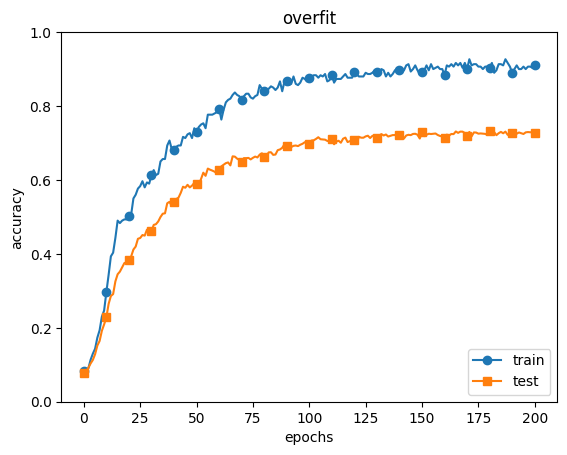

In [9]:
markers = {'train': 'o', 'test': 's'}
x = np.arange(max_epochs)
plt.plot(x, train_acc_list, marker='o', label='train', markevery=10)
plt.plot(x, test_acc_list, marker='s', label='test', markevery=10)
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.title("overfit")
plt.show()

In [10]:
use_dropout = True  # 드롭아웃을 쓰지 않을 때는 False
dropout_ratio = 0.2


In [13]:
class Trainer:
    """신경망 훈련을 대신 해주는 클래스
    """
    def __init__(self, network, x_train, t_train, x_test, t_test,
                 epochs=20, mini_batch_size=100,
                 optimizer='SGD', optimizer_param={'lr':0.01}, 
                 evaluate_sample_num_per_epoch=None, verbose=True):
        self.network = network
        self.verbose = verbose
        self.x_train = x_train
        self.t_train = t_train
        self.x_test = x_test
        self.t_test = t_test
        self.epochs = epochs
        self.batch_size = mini_batch_size
        self.evaluate_sample_num_per_epoch = evaluate_sample_num_per_epoch

        # optimzer
        optimizer_class_dict = {'sgd':SGD}
        self.optimizer = optimizer_class_dict[optimizer.lower()](**optimizer_param)
        
        self.train_size = x_train.shape[0]
        self.iter_per_epoch = max(self.train_size / mini_batch_size, 1)
        self.max_iter = int(epochs * self.iter_per_epoch)
        self.current_iter = 0
        self.current_epoch = 0
        
        self.train_loss_list = []
        self.train_acc_list = []
        self.test_acc_list = []

    def train_step(self):
        batch_mask = np.random.choice(self.train_size, self.batch_size)
        x_batch = self.x_train[batch_mask]
        t_batch = self.t_train[batch_mask]
        
        grads = self.network.gradient(x_batch, t_batch)
        self.optimizer.update(self.network.params, grads)
        
        loss = self.network.loss(x_batch, t_batch)
        self.train_loss_list.append(loss)
        if self.verbose: print("train loss:" + str(loss))
        
        if self.current_iter % self.iter_per_epoch == 0:
            self.current_epoch += 1
            
            x_train_sample, t_train_sample = self.x_train, self.t_train
            x_test_sample, t_test_sample = self.x_test, self.t_test
            if not self.evaluate_sample_num_per_epoch is None:
                t = self.evaluate_sample_num_per_epoch
                x_train_sample, t_train_sample = self.x_train[:t], self.t_train[:t]
                x_test_sample, t_test_sample = self.x_test[:t], self.t_test[:t]
                
            train_acc = self.network.accuracy(x_train_sample, t_train_sample)
            test_acc = self.network.accuracy(x_test_sample, t_test_sample)
            self.train_acc_list.append(train_acc)
            self.test_acc_list.append(test_acc)

            if self.verbose: print("=== epoch:" + str(self.current_epoch) + ", train acc:" + str(train_acc) + ", test acc:" + str(test_acc) + " ===")
        self.current_iter += 1

    def train(self):
        for i in range(self.max_iter):
            self.train_step()

        test_acc = self.network.accuracy(self.x_test, self.t_test)

        if self.verbose:
            print("=============== Final Test Accuracy ===============")
            print("test acc:" + str(test_acc))

In [14]:
network = MultiLayerNetExtend(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100],
                              output_size=10, use_dropout=use_dropout, dropout_ration=dropout_ratio)
trainer = Trainer(network, x_train, t_train, x_test, t_test,
                  epochs=301, mini_batch_size=100,
                  optimizer='sgd', optimizer_param={'lr': 0.01}, verbose=True)
trainer.train()

train_acc_list, test_acc_list = trainer.train_acc_list, trainer.test_acc_list

train loss:2.2820909692968145
=== epoch:1, train acc:0.10666666666666667, test acc:0.1026 ===
train loss:2.323655415412531
train loss:2.3002779811829446
train loss:2.312114225730356
=== epoch:2, train acc:0.11333333333333333, test acc:0.1017 ===
train loss:2.312875324026078
train loss:2.2713643585431
train loss:2.3095861217823113
=== epoch:3, train acc:0.11333333333333333, test acc:0.1021 ===
train loss:2.2854842372494337
train loss:2.3262429993783886
train loss:2.309662390491391
=== epoch:4, train acc:0.11, test acc:0.1026 ===
train loss:2.303427141726049
train loss:2.296722585021006
train loss:2.3064362028648304
=== epoch:5, train acc:0.11, test acc:0.1034 ===
train loss:2.3040302610532084
train loss:2.2961696394044377
train loss:2.2958063824764032
=== epoch:6, train acc:0.11666666666666667, test acc:0.104 ===
train loss:2.3115078462280745
train loss:2.288411899630297
train loss:2.2688713542572874
=== epoch:7, train acc:0.11666666666666667, test acc:0.106 ===
train loss:2.28913833915

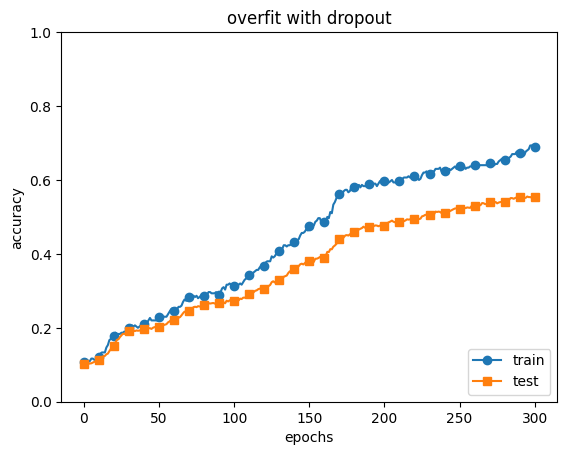

In [15]:
markers = {'train': 'o', 'test': 's'}
x = np.arange(len(train_acc_list))
plt.plot(x, train_acc_list, marker='o', label='train', markevery=10)
plt.plot(x, test_acc_list, marker='s', label='test', markevery=10)
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.title("overfit with dropout")
plt.show()